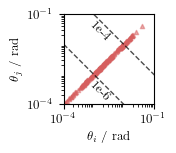

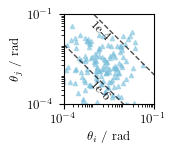

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import graph_style as gs
import fig_helper as fh
gs.set_graph_style(1)

l_scale = 0.0002
g_scale = 0.06
size = 200
theta_l1 = abs(np.random.normal(loc=0.0, scale=l_scale, size=size))
theta_l2 = abs(np.random.normal(loc=0.0, scale=l_scale, size=size))
theta_g = abs(np.random.normal(loc=0.0, scale=g_scale, size=size))


theta_1 = theta_l1 + theta_g
theta_2 = theta_l2 + theta_g
theta_3 = abs(np.random.normal(loc=0.0, scale=l_scale+g_scale, size=size))

def plot_theta_scatter(theta_a, theta_b, f_name, colour):
    fig_width = 0.9
    fig_height = 0.9
    fig = plt.figure(figsize=(fig_width, fig_height))
    ax = fig.add_axes([0, 0, 1, 1])  # full canvas
    ax.scatter(theta_a**2, theta_b**2, alpha=0.5, label=r"$\theta_{\mathrm{com}}<\theta_{\mathrm{diff}}$", color=colour)
    lim = 0.1
    ax.set_xlim(1e-4, lim)
    ax.set_ylim(1e-4, lim)
    ax.set_xlabel(r"$\theta_i$  / rad")
    ax.set_ylabel(r"$\theta_j$  / rad")
    ax.grid(False)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([1e-4, lim])
    ax.set_yticks([1e-4, lim])

    # plot theta_i^2 * theta_j^2 = 0.1^2 as a dashed line
    thresholds = [1e-6, 1e-4]
    for t, l in zip(thresholds, ['1e-6', '1e-4']):
        x = np.linspace(0.0001, 1, 1000)
        y = t / x
        ax.plot(x, y, color="black", linestyle='--', alpha=0.7, label=r"$\theta_i^2 \theta_j^2 = {:.2f}^2$".format(t))
        # write text just below line on right hand side of plot giving threshold value, also make text tilt

        text_x = 7e-4
        angle = -45
        ax.text(text_x, t / (text_x*11), l, fontsize=9, rotation=angle)

    # save fig
    # fig.savefig(f_path, bbox_inches = "tight", transparent=True)

f_path = "..\\pdf_figure\\f1_theta_com_scatter.pdf"
plot_theta_scatter(theta_1, theta_2, f_path, colour=gs.get_color(2))
f_path = "..\\pdf_figure\\f1_thetal_diff_scatter.pdf"
plot_theta_scatter(theta_3, theta_2, f_path, colour=gs.get_color(5))
